In [135]:
import numpy as np
import matplotlib.pyplot as plt
import IPython
import numpy as np
import os
from IPython.display import Image as Image2
from numpy import genfromtxt
import pickle
from IPython import embed
from PIL import Image, ImageDraw, ImageFont
from scipy.io import loadmat

import seaborn as sns
import pandas as pd
%matplotlib inline
from scipy import ndimage
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import matplotlib.patches as mpatches

In [ ]:
df_whale = pd.read_csv('../data/sperm-whale-dialogues.csv')
df_whale.columns

Index(['REC', 'nClicks', 'Duration', 'ICI1', 'ICI2', 'ICI3', 'ICI4', 'ICI5',
       'ICI6', 'ICI7', 'ICI8', 'ICI9', 'ICI10', 'ICI11', 'ICI12', 'ICI13',
       'ICI14', 'ICI15', 'ICI16', 'ICI17', 'ICI18', 'ICI19', 'ICI20', 'ICI21',
       'ICI22', 'ICI23', 'ICI24', 'ICI25', 'ICI26', 'ICI27', 'ICI28', 'Whale',
       'TsTo'],
      dtype='str')

In [136]:
# df_whale.iloc[:,3:32]

for c in range(3, 32):
    counts, bin_edges = np.histogram(df_whale.iloc[:, c], bins=1000)
    max_count = counts.max()
    display(max_count)


np.int64(28)

np.int64(23)

np.int64(68)

np.int64(345)

np.int64(3296)

...

np.int64(3839)

np.int64(3839)

np.int64(3839)

np.int64(3839)

np.int64(1694)

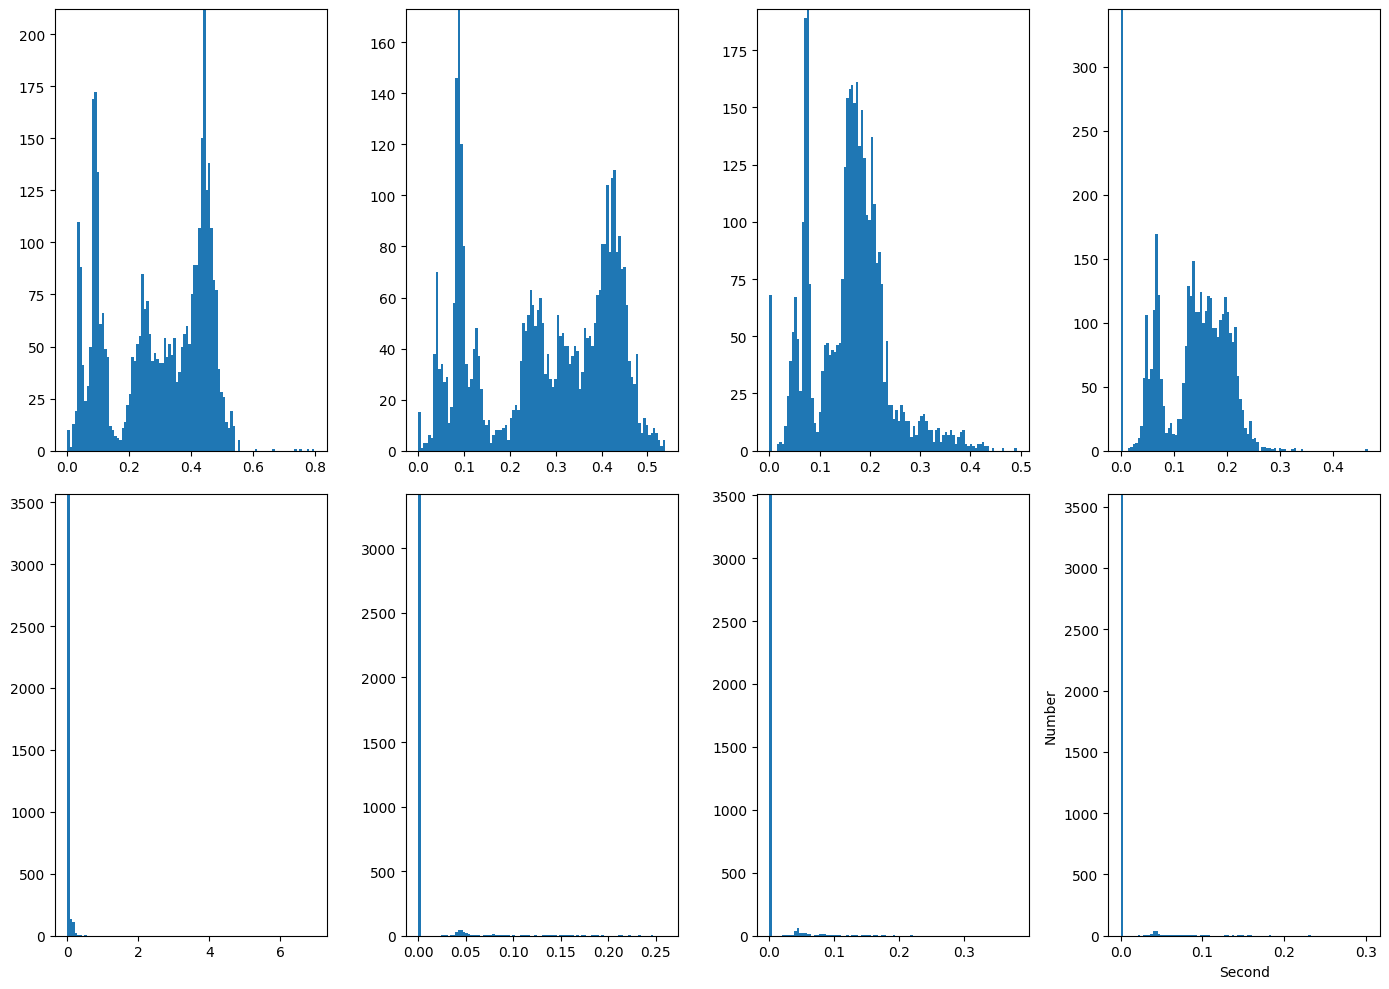

In [42]:

from matplotlib import colors
from matplotlib.ticker import PercentFormatter


n_bins = 100

# Generate two normal distributions
fig, axs = plt.subplots(2, 4, figsize=(14, 10), tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
for row in range(0, 2):
    for col in range(0, 4):
        n, bins, patches = axs[row,col].hist(df_whale.iloc[:, 4 * row + col + 3], bins=n_bins)
        max_count = n.max()
        axs[row,col].set_ylim(0, max_count)
        
        
plt.xlabel('Second')
plt.ylabel('Number')

plt.show()

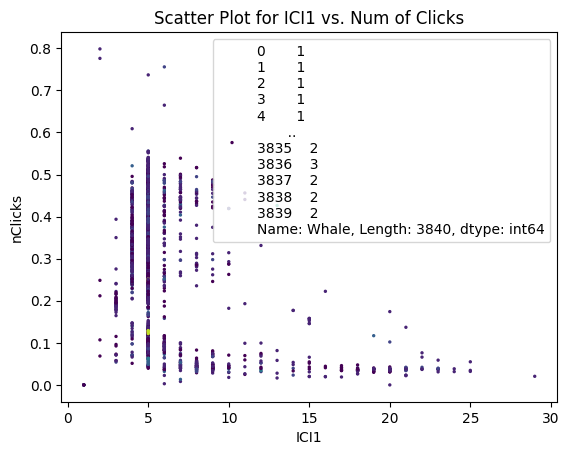

In [83]:
plt.scatter(df_whale['nClicks'], df_whale['ICI1'], s=2, c=df_whale['Whale'], label=df_whale['Whale'])
plt.title('Scatter Plot for ICI1 vs. Num of Clicks')
plt.xlabel('ICI1')
plt.ylabel('nClicks')
plt.legend()

plt.show()

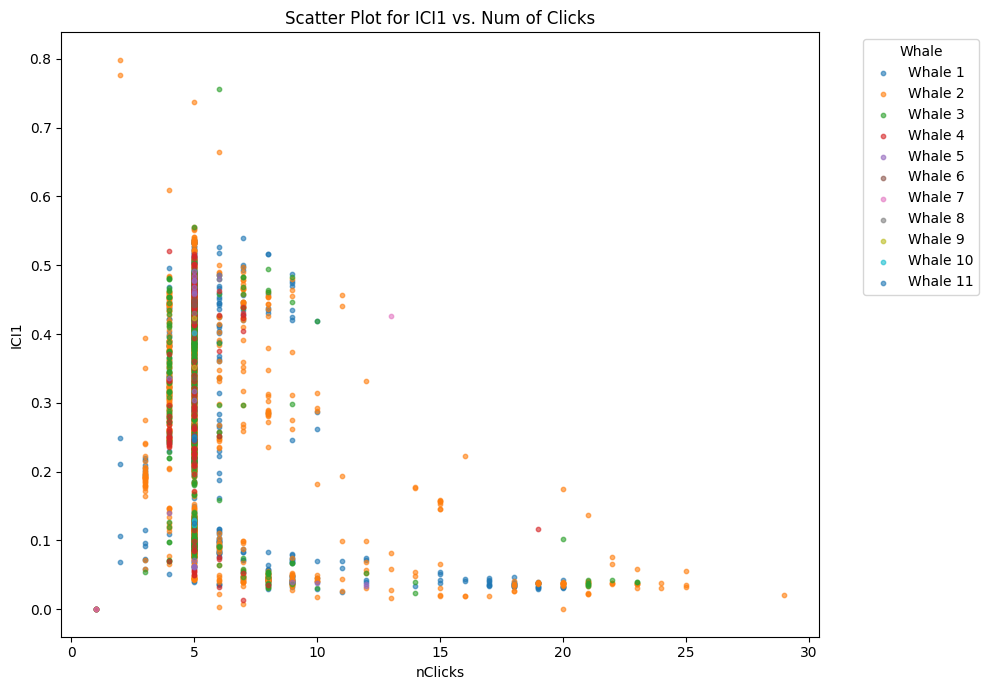

In [85]:
fig, ax = plt.subplots(figsize=(10, 7))

for whale_id, group in df_whale.groupby('Whale'):
    ax.scatter(group['nClicks'], group['ICI1'], s=10, label=f'Whale {whale_id}', alpha=0.6)

ax.set_title('Scatter Plot for ICI1 vs. Num of Clicks')
ax.set_xlabel('nClicks')
ax.set_ylabel('ICI1')
ax.legend(title='Whale', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


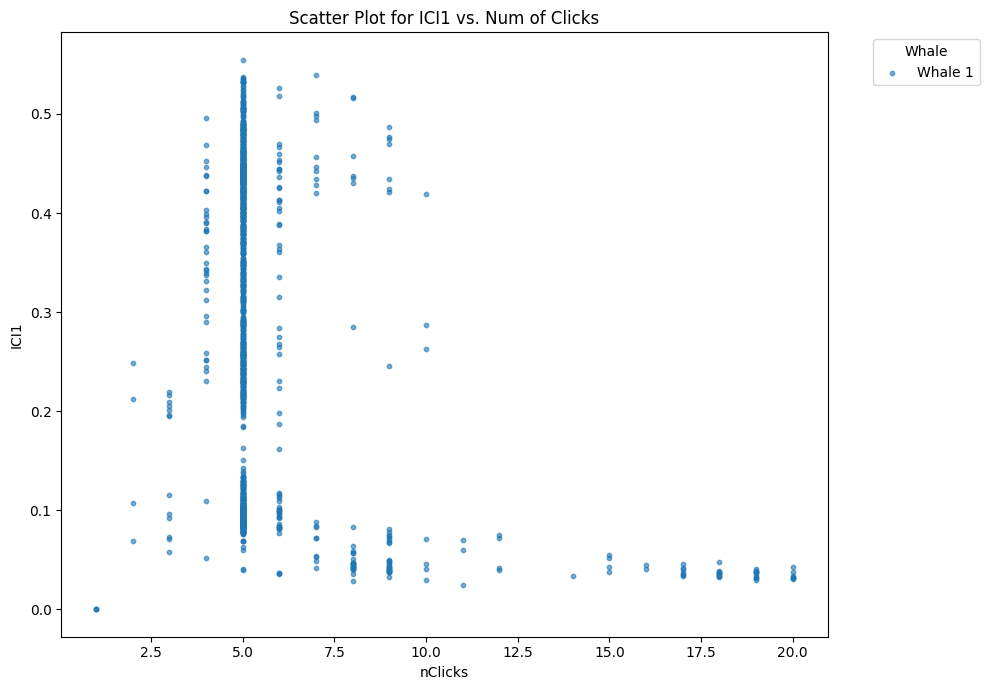

In [131]:
fig, ax = plt.subplots(figsize=(10, 7))

df_12 = df_whale[(df_whale['Whale'] == 1)]

for whale_id, group in df_12.groupby('Whale'):
    ax.scatter(group['nClicks'], group['ICI1'], s=10, label=f'Whale {whale_id}', alpha=0.6)

ax.set_title('Scatter Plot for ICI1 vs. Num of Clicks')
ax.set_xlabel('nClicks')
ax.set_ylabel('ICI1')
ax.legend(title='Whale', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


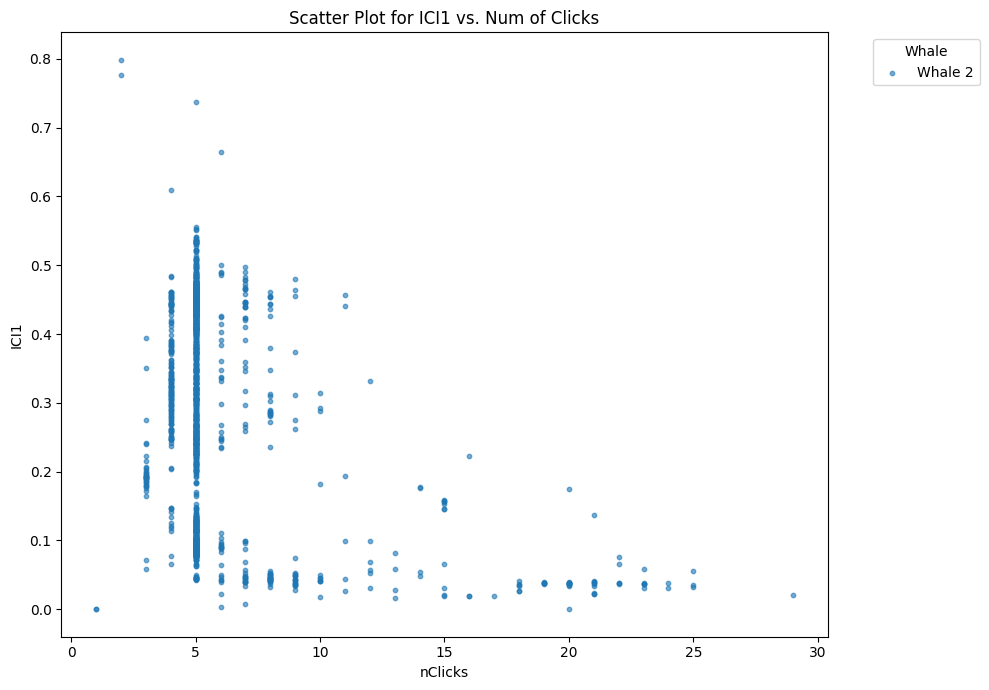

In [132]:
fig, ax = plt.subplots(figsize=(10, 7))

df_12 = df_whale[(df_whale['Whale'] == 2)]

for whale_id, group in df_12.groupby('Whale'):
    ax.scatter(group['nClicks'], group['ICI1'], s=10, label=f'Whale {whale_id}', alpha=0.6)

ax.set_title('Scatter Plot for ICI1 vs. Num of Clicks')
ax.set_xlabel('nClicks')
ax.set_ylabel('ICI1')
ax.legend(title='Whale', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [81]:
# len(df_whale.iloc[:,31].unique())
# df_whale.iloc[:,31].unique()
df_whale[df_whale['Whale'] == 3].count()

REC         543
nClicks     543
Duration    543
ICI1        543
ICI2        543
ICI3        543
ICI4        543
ICI5        543
ICI6        543
ICI7        543
ICI8        543
ICI9        543
ICI10       543
ICI11       543
ICI12       543
ICI13       543
ICI14       543
ICI15       543
ICI16       543
ICI17       543
ICI18       543
ICI19       543
ICI20       543
ICI21       543
ICI22       543
ICI23       543
ICI24       543
ICI25       543
ICI26       543
ICI27       543
ICI28       543
Whale       543
TsTo        543
dtype: int64

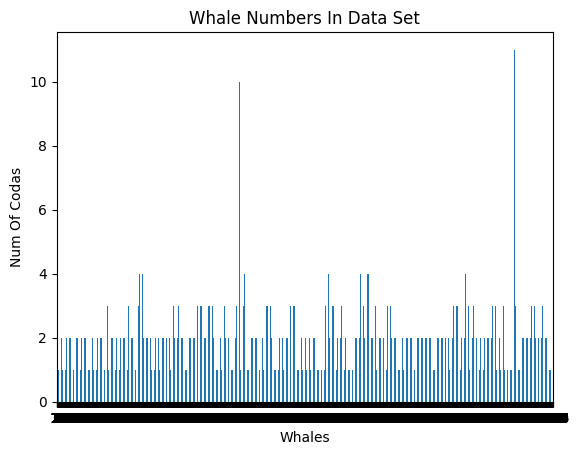

In [96]:
df=df_whale.iloc[:, 31]
df.plot.bar(x='Whale', rot=0)
plt.title('Whale Numbers In Data Set')
plt.xlabel('Whales')
plt.ylabel('Num Of Codas')
plt.show()

In [114]:
df=df_whale.iloc[:, 31]
df.value_counts()

Whale
2     1694
1     1394
3      543
4      164
5       23
6        7
10       5
11       4
7        2
9        2
8        2
Name: count, dtype: int64

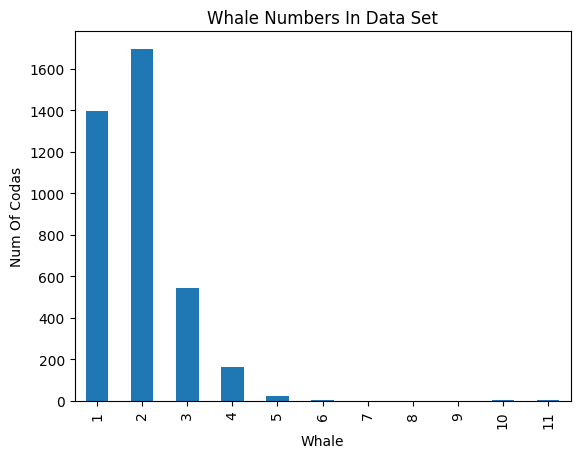

In [ ]:
df_whale['Whale'].value_counts().sort_index().plot.bar()
plt.title('Whale Numbers In Data Set')
plt.xlabel('Whale')
plt.ylabel('Num Of Codas')
plt.show()